In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Loading dataset

In [3]:
df = pd.read_excel('/content/drive/My Drive/Data Model - Pizza Sales.xlsx')
df

,order_details_id,order_id,pizza_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name
0,1,1,hawaiian_m,1,2015-01-01,11:38:36,13.25,13.25,M,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",The Hawaiian Pizza
1,2,2,classic_dlx_m,1,2015-01-01,11:57:40,16.00,16.00,M,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",The Classic Deluxe Pizza
2,3,2,five_cheese_l,1,2015-01-01,11:57:40,18.50,18.50,L,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",The Five Cheese Pizza
3,4,2,ital_supr_l,1,2015-01-01,11:57:40,20.75,20.75,L,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",The Italian Supreme Pizza
4,5,2,mexicana_m,1,2015-01-01,11:57:40,16.00,16.00,M,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza
...,...,...,...,...,...,...,...,...,...,...,...,...
48615,48616,21348,ckn_alfredo_m,1,2015-12-31,21:23:10,16.75,16.75,M,Chicken,"Chicken, Red Onions, Red Peppers, Mushrooms, A...",The Chicken Alfredo Pizza
48616,48617,21348,four_cheese_l,1,2015-12-31,21:23:10,17.95,17.95,L,Veggie,"Ricotta Cheese, Gorgonzola Piccante Cheese, Mo...",The Four Cheese Pizza
48617,48618,21348,napolitana_s,1,2015-12-31,21:23:10,12.00,12.00,S,Classic,"Tomatoes, Anchovies, Green Olives, Red Onions,...",The Napolitana Pizza
48618,48619,21349,mexicana_l,1,2015-12-31,22:09:54,20.25,20.25,L,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza


## Exploratory some information about dataset

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   order_details_id   48620 non-null  int64         
 1   order_id           48620 non-null  int64         
 2   pizza_id           48620 non-null  object        
 3   quantity           48620 non-null  int64         
 4   order_date         48620 non-null  datetime64[ns]
 5   order_time         48620 non-null  object        
 6   unit_price         48620 non-null  float64       
 7   total_price        48620 non-null  float64       
 8   pizza_size         48620 non-null  object        
 9   pizza_category     48620 non-null  object        
 10  pizza_ingredients  48620 non-null  object        
 11  pizza_name         48620 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(3), object(6)
memory usage: 4.5+ MB


In [5]:
df.describe()

,order_details_id,order_id,quantity,order_date,unit_price,total_price
count,48620.000000,48620.000000,48620.000000,48620,48620.000000,48620.000000
mean,24310.500000,10701.479761,1.019622,2015-06-29 11:03:43.611682560,16.494132,16.821474
min,1.000000,1.000000,1.000000,2015-01-01 00:00:00,9.750000,9.750000
25%,12155.750000,5337.000000,1.000000,2015-03-31 00:00:00,12.750000,12.750000
50%,24310.500000,10682.500000,1.000000,2015-06-28 00:00:00,16.500000,16.500000
75%,36465.250000,16100.000000,1.000000,2015-09-28 00:00:00,20.250000,20.500000
max,48620.000000,21350.000000,4.000000,2015-12-31 00:00:00,35.950000,83.000000
std,14035.529381,6180.119770,0.143077,NaN,3.621789,4.437398


In [6]:
df.shape

(48620, 12)

In [7]:
df.isnull().sum()

,0
order_details_id,0
order_id,0
pizza_id,0
quantity,0
order_date,0
order_time,0
unit_price,0
total_price,0
pizza_size,0
pizza_category,0


In [8]:
df.columns

Index(['order_details_id', 'order_id', 'pizza_id', 'quantity', 'order_date',
       'order_time', 'unit_price', 'total_price', 'pizza_size',
       'pizza_category', 'pizza_ingredients', 'pizza_name'],
      dtype='object')

In [9]:
df['order_time'] = df['order_time'].astype('string') #convert to a string data type
df[['Hour', 'Minute', 'Second']] = df['order_time'].str.split(':', expand=True) # takes the order_time column and splits it at each colon (:) into three separate components.
df['Hour'].value_counts() #calculates and displays the frequency of each unique value in the newly created Hour column. This shows how many orders were placed in each hour.

,count
Hour,
12,6543
13,6203
18,5359
17,5143
19,4350
16,4185
14,3521
20,3487
15,3170


In [10]:
df

,order_details_id,order_id,pizza_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name,Hour,Minute,Second
0,1,1,hawaiian_m,1,2015-01-01,11:38:36,13.25,13.25,M,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",The Hawaiian Pizza,11,38,36
1,2,2,classic_dlx_m,1,2015-01-01,11:57:40,16.00,16.00,M,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",The Classic Deluxe Pizza,11,57,40
2,3,2,five_cheese_l,1,2015-01-01,11:57:40,18.50,18.50,L,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",The Five Cheese Pizza,11,57,40
3,4,2,ital_supr_l,1,2015-01-01,11:57:40,20.75,20.75,L,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",The Italian Supreme Pizza,11,57,40
4,5,2,mexicana_m,1,2015-01-01,11:57:40,16.00,16.00,M,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza,11,57,40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48615,48616,21348,ckn_alfredo_m,1,2015-12-31,21:23:10,16.75,16.75,M,Chicken,"Chicken, Red Onions, Red Peppers, Mushrooms, A...",The Chicken Alfredo Pizza,21,23,10
48616,48617,21348,four_cheese_l,1,2015-12-31,21:23:10,17.95,17.95,L,Veggie,"Ricotta Cheese, Gorgonzola Piccante Cheese, Mo...",The Four Cheese Pizza,21,23,10
48617,48618,21348,napolitana_s,1,2015-12-31,21:23:10,12.00,12.00,S,Classic,"Tomatoes, Anchovies, Green Olives, Red Onions,...",The Napolitana Pizza,21,23,10
48618,48619,21349,mexicana_l,1,2015-12-31,22:09:54,20.25,20.25,L,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza,22,09,54


## Data visualization

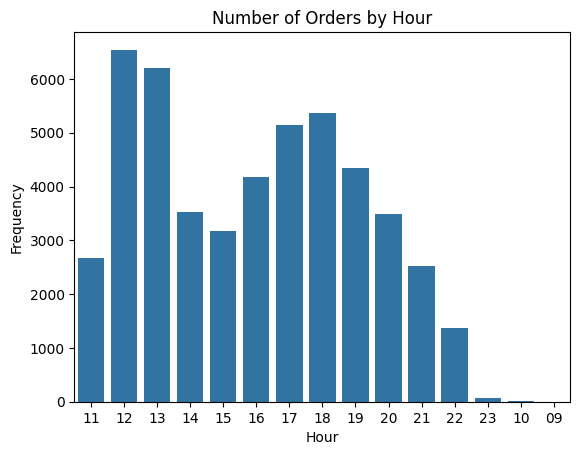

In [11]:
sns.countplot(x='Hour', data=df)
plt.title('Number of Orders by Hour')
plt.xlabel('Hour')
plt.ylabel('Frequency')
plt.show()

In [12]:
df['order_year'] = pd.DatetimeIndex(df['order_date']).year
df['order_year'].value_counts()

,count
order_year,
2015,48620


In [13]:
df['order_dates'] = df['order_date'].dt.day_name()
df['order_dates'].value_counts()

,count
order_dates,
Friday,8106
Saturday,7355
Thursday,7323
Wednesday,6797
Tuesday,6753
Monday,6369
Sunday,5917


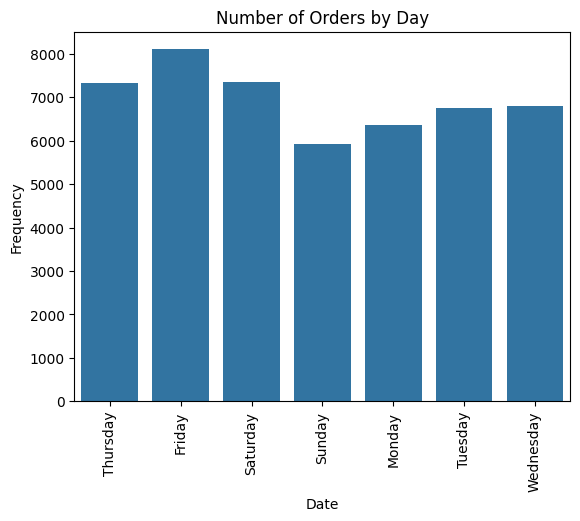

In [14]:
sns.countplot(x='order_dates', data=df)
plt.xticks(rotation=90)
plt.title('Number of Orders by Day')
plt.xlabel('Date')
plt.ylabel('Frequency')
plt.show()

In [15]:
df['order_month'] = pd.DatetimeIndex(df['order_date']).month
df.loc[(df['order_month'] == 1), 'order_month'] ='January'
df.loc[(df['order_month'] == 2), 'order_month'] ='February'
df.loc[(df['order_month'] == 3), 'order_month'] ='March'
df.loc[(df['order_month'] == 4), 'order_month'] ='April'
df.loc[(df['order_month'] == 5), 'order_month'] ='May'
df.loc[(df['order_month'] == 6), 'order_month'] ='June'
df.loc[(df['order_month'] == 7), 'order_month'] ='July'
df.loc[(df['order_month'] == 8), 'order_month'] ='August'
df.loc[(df['order_month'] == 9), 'order_month'] ='September'
df.loc[(df['order_month'] == 10), 'order_month'] ='October'
df.loc[(df['order_month'] == 11), 'order_month'] ='November'
df.loc[(df['order_month'] == 12), 'order_month'] ='December'
df['order_month'].value_counts()

/tmp/ipykernel_1969/3770772887.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'January' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.
  df.loc[(df['order_month'] == 1), 'order_month'] ='January'


,count
order_month,
July,4301
May,4239
March,4186
November,4185
January,4156
August,4094
April,4067
June,4025
February,3892


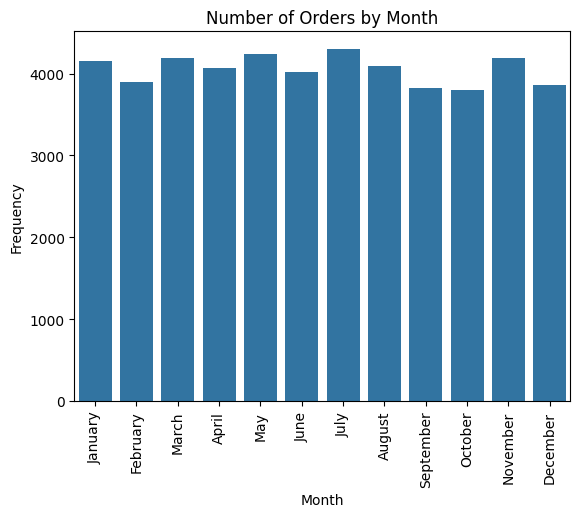

In [16]:
sns.countplot(x='order_month', data=df)
plt.xticks(rotation=90)
plt.title('Number of Orders by Month')
plt.xlabel('Month')
plt.ylabel('Frequency')
plt.show()

In [17]:
df.pizza_id.value_counts()

,count
pizza_id,
big_meat_s,1811
thai_ckn_l,1365
five_cheese_l,1359
four_cheese_l,1273
classic_dlx_m,1159
...,...
mexicana_s,160
calabrese_s,99
ckn_alfredo_s,96


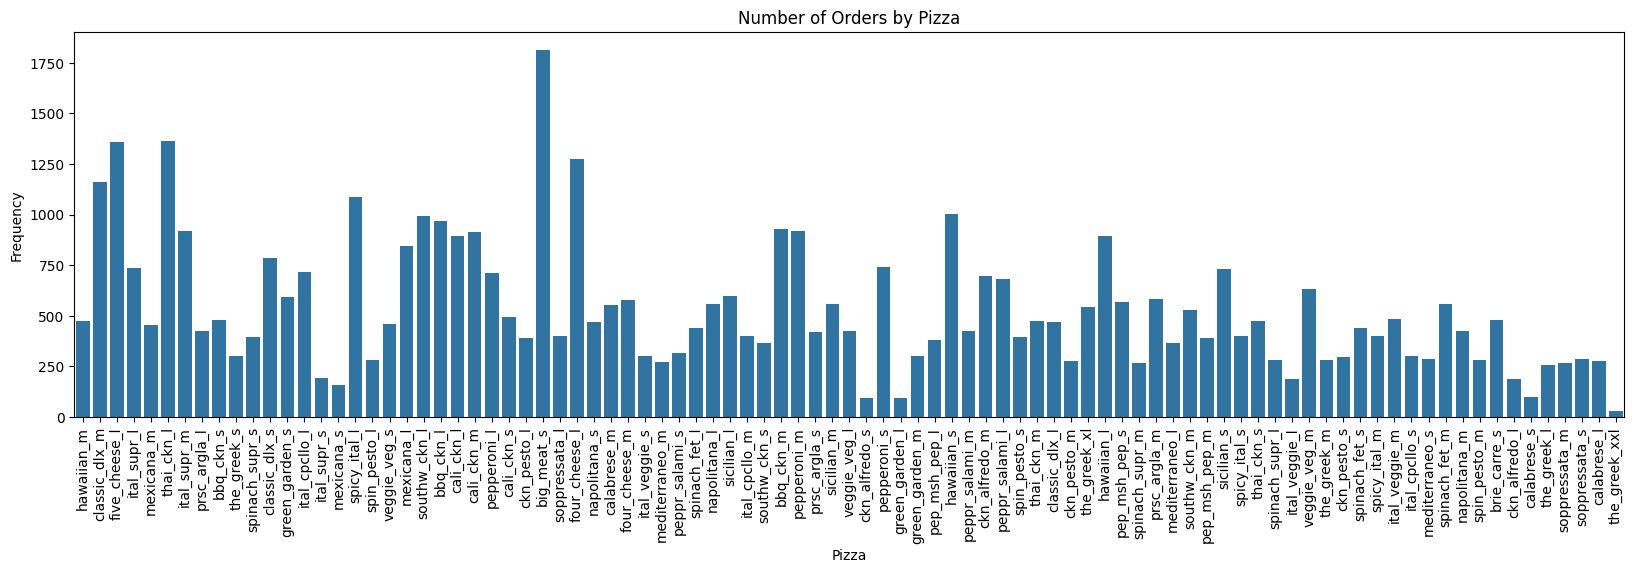

In [18]:
fig, ax = plt.subplots(figsize=(20, 5))
sns.countplot(x='pizza_id', data=df, ax=ax)
plt.xticks(rotation=90)
plt.title('Number of Orders by Pizza')
plt.xlabel('Pizza')
plt.ylabel('Frequency')
plt.show()

In [19]:
df.quantity.value_counts()

,count
quantity,
1,47693
2,903
3,21
4,3


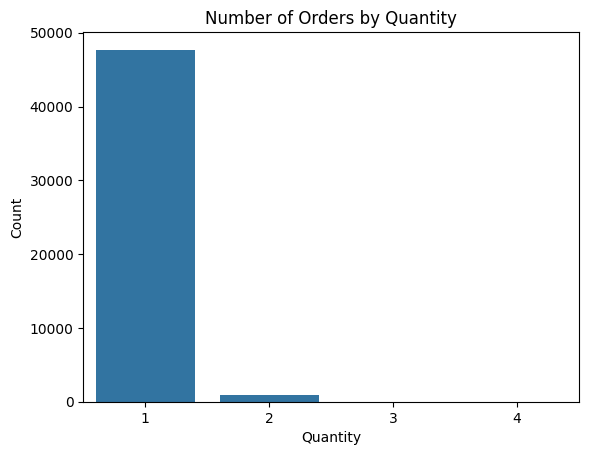

In [20]:
sns.countplot(data=df, x='quantity')
plt.title('Number of Orders by Quantity')
plt.xlabel('Quantity')
plt.ylabel('Count')
plt.show()

In [21]:
df.pizza_size.value_counts()

,count
pizza_size,
L,18526
M,15385
S,14137
XL,544
XXL,28


/tmp/ipykernel_1969/811584503.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='pizza_size',palette='Reds')


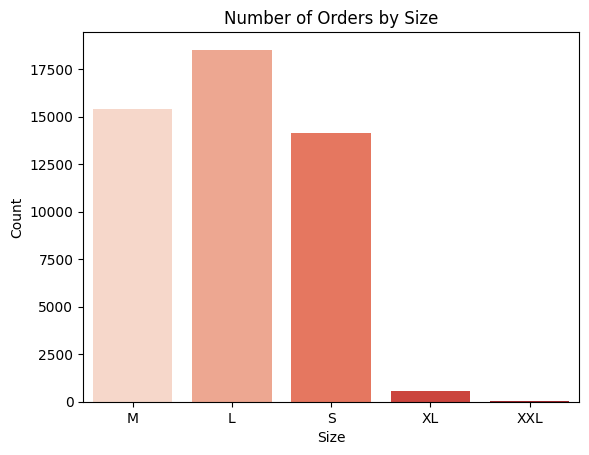

In [22]:
sns.countplot(data=df, x='pizza_size',palette='Reds')
plt.title('Number of Orders by Size')
plt.xlabel('Size')
plt.ylabel('Count')
plt.show()

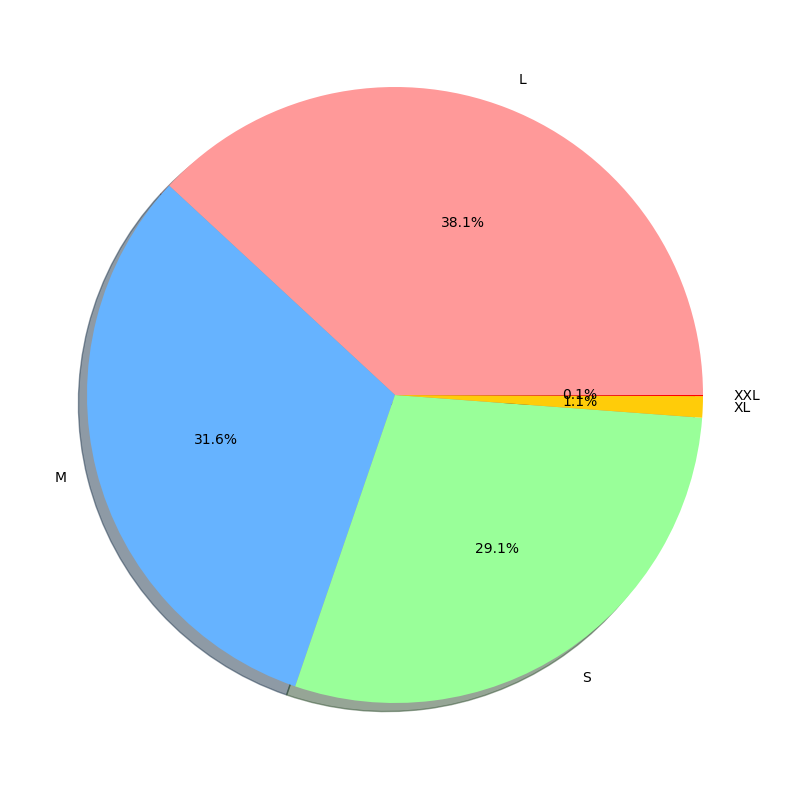

In [23]:
labels = df['pizza_size'].value_counts().index
sizes = df['pizza_size'].value_counts()
plt.figure(figsize=(10, 10))
colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc09', 'red']
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', shadow=True)
plt.show()

In [24]:
df.pizza_category.value_counts()

,count
pizza_category,
Classic,14579
Supreme,11777
Veggie,11449
Chicken,10815


/tmp/ipykernel_1969/1868589456.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='pizza_category', palette='Greens')


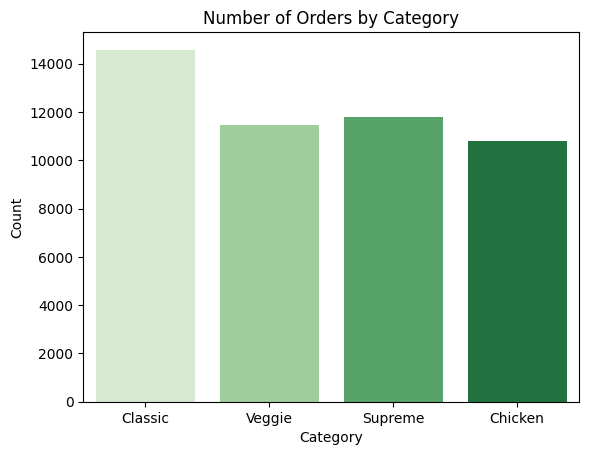

In [25]:
sns.countplot(data=df, x='pizza_category', palette='Greens')
plt.title('Number of Orders by Category')
plt.xlabel('Category')
plt.ylabel('Count')
plt.show()

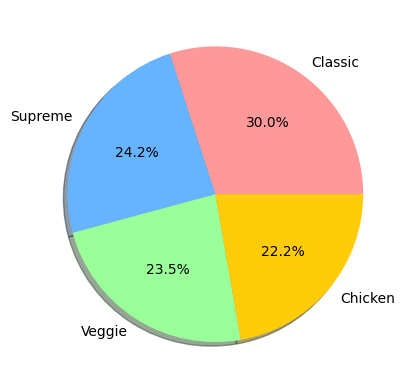

In [26]:
labels = df['pizza_category'].value_counts().index
sizes = df['pizza_category'].value_counts()
colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc09', 'red']
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', shadow=True)
plt.show()

In [27]:
df.Hour.value_counts()

,count
Hour,
12,6543
13,6203
18,5359
17,5143
19,4350
16,4185
14,3521
20,3487
15,3170


/tmp/ipykernel_1969/869680543.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Hour', palette='Oranges')


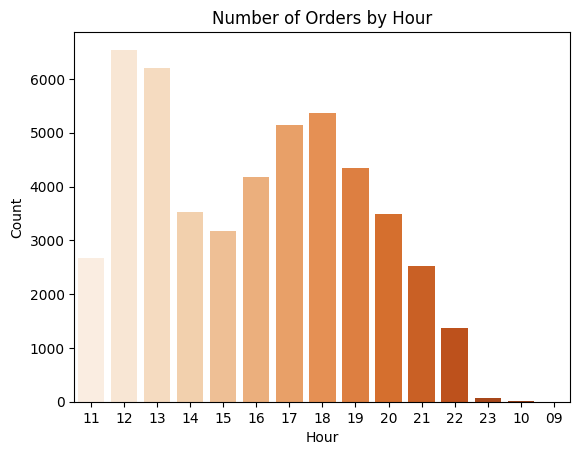

In [28]:
sns.countplot(data=df, x='Hour', palette='Oranges')
plt.title('Number of Orders by Hour')
plt.xlabel('Hour')
plt.ylabel('Count')
plt.show()

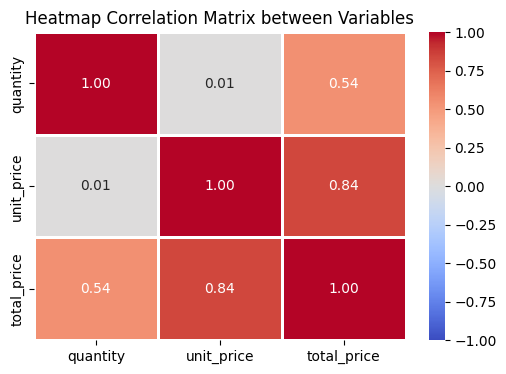

In [29]:
numeric_cols = df[['quantity', 'unit_price', 'total_price']]
corr_matrix = numeric_cols.corr()

plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1, linewidths=1)

plt.title('Heatmap Correlation Matrix between Variables')
plt.show()